# Model 1 — Baseline CNN

**Group**: Group 14  
**Members**: P1, P2, P3, P4, P5 *(update with real names)*  
**Model owner**: P1  
**Architecture**: Simple Conv2D stack (3 blocks)  
**Dataset**: NIH Malaria Cell Images — Parasitized vs Uninfected  
**Date**: June 2026

---
This notebook establishes the performance baseline for the group.  
All 5 members must run this notebook and confirm matching train/val/test sizes before forking for individual models.

## 1. Environment Setup
Set all random seeds for reproducibility and verify GPU availability.

In [1]:
import os, sys, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', gpus if gpus else 'None — training on CPU')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset Download
Download the NIH Malaria dataset via `kagglehub`. The path is resolved dynamically so this notebook runs on any machine.

In [2]:
import kagglehub

path = kagglehub.dataset_download('iarunava/cell-images-for-detecting-malaria')
print('Downloaded to:', path)

# Find the subfolder that contains Parasitized/ and Uninfected/
DATA_DIR = None
for root, dirs, _ in os.walk(path):
    if 'Parasitized' in dirs and 'Uninfected' in dirs:
        DATA_DIR = root
        break

assert DATA_DIR is not None, 'Could not locate Parasitized/Uninfected folders'
print('DATA_DIR:', DATA_DIR)
print('Parasitized images:', len(os.listdir(os.path.join(DATA_DIR, 'Parasitized'))))
print('Uninfected images: ', len(os.listdir(os.path.join(DATA_DIR, 'Uninfected'))))

Using Colab cache for faster access to the 'cell-images-for-detecting-malaria' dataset.
Downloaded to: /kaggle/input/cell-images-for-detecting-malaria
DATA_DIR: /kaggle/input/cell-images-for-detecting-malaria/cell_images
Parasitized images: 13780
Uninfected images:  13780


## 3. Shared Helper Functions
All helper functions are defined inline — this notebook runs independently on any platform (local or Google Colab) without needing `utils.py`.

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
)

# ── Constants
IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
SEED        = 42
CLASS_NAMES = ['Parasitized', 'Uninfected']
TRAIN_SPLIT = 0.80
VAL_SPLIT   = 0.10
TEST_SPLIT  = 0.10

os.makedirs('figures',     exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

# ── Augmentation layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name='data_augmentation')

# ── Dataset loader
def load_dataset(data_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE):
    full_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='binary',
        class_names=CLASS_NAMES,
        image_size=image_size,
        batch_size=None,
        shuffle=True,
        seed=SEED,
    )
    total   = sum(1 for _ in full_ds)
    n_train = int(total * TRAIN_SPLIT)
    n_val   = int(total * VAL_SPLIT)
    train_ds  = full_ds.take(n_train)
    remaining = full_ds.skip(n_train)
    val_ds    = remaining.take(n_val)
    test_ds   = remaining.skip(n_val)
    normalise = lambda img, lbl: (tf.cast(img, tf.float32) / 255.0, lbl)
    AUTOTUNE  = tf.data.AUTOTUNE
    train_ds = (train_ds.map(normalise, num_parallel_calls=AUTOTUNE)
                .cache().shuffle(1000, seed=SEED).batch(batch_size).prefetch(AUTOTUNE))
    val_ds   = (val_ds.map(normalise, num_parallel_calls=AUTOTUNE)
                .cache().batch(batch_size).prefetch(AUTOTUNE))
    test_ds  = (test_ds.map(normalise, num_parallel_calls=AUTOTUNE)
                .cache().batch(batch_size).prefetch(AUTOTUNE))
    return train_ds, val_ds, test_ds

# ── Metrics
def evaluate_model(model, test_ds):
    y_true, y_pred_prob = [], []
    for images, labels in test_ds:
        preds = model(images, training=False).numpy()

        y_pred_prob.extend(preds.flatten())
        y_true.extend(labels.numpy().flatten())
    y_true      = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred      = (y_pred_prob >= 0.5).astype(int)
    return {
        'accuracy':  round(accuracy_score(y_true, y_pred),     4),
        'precision': round(precision_score(y_true, y_pred),    4),
        'recall':    round(recall_score(y_true, y_pred),       4),
        'f1':        round(f1_score(y_true, y_pred),           4),
        'auc':       round(roc_auc_score(y_true, y_pred_prob), 4),
        'y_true':    y_true,
        'y_pred':    y_pred,
        'y_prob':    y_pred_prob,
    }

# ── Learning curves
def plot_learning_curves(history, experiment_name, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Learning curves — {experiment_name}', fontsize=14, fontweight='bold')
    axes[0].plot(history.history['loss'],     label='Train loss',     linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val loss',       linewidth=2, linestyle='--')
    axes[0].set_title('Loss over epochs'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['accuracy'],     label='Train accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val accuracy',   linewidth=2, linestyle='--')
    axes[1].set_title('Accuracy over epochs'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    final_train = history.history['accuracy'][-1]
    final_val   = history.history['val_accuracy'][-1]
    gap = final_train - final_val
    if gap > 0.05:
        print(f'Overfitting detected: train {final_train:.3f} vs val {final_val:.3f} (gap={gap:.3f})')
    elif gap < -0.02:
        print(f'Underfitting detected: train {final_train:.3f} vs val {final_val:.3f}')
    else:
        print(f'Good fit: train {final_train:.3f} vs val {final_val:.3f} (gap={gap:.3f})')

# ── Confusion matrix
def plot_confusion_matrix(metrics_dict, class_names, experiment_name, save_path=None):
    cm  = confusion_matrix(metrics_dict['y_true'], metrics_dict['y_pred'])
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax, linewidths=0.5)
    ax.set_title(f'Confusion matrix — {experiment_name}', fontsize=13, fontweight='bold', pad=14)
    ax.set_ylabel('True label', fontsize=11); ax.set_xlabel('Predicted label', fontsize=11)
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.12,
            f'TP={tp}  TN={tn}  FP={fp}  FN={fn}  |  Sensitivity={tp/(tp+fn):.3f}  Specificity={tn/(tn+fp):.3f}',
            ha='center', va='top', transform=ax.transAxes, fontsize=10, color='dimgray')
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ── ROC curve
def plot_roc_curve(metrics_dict, experiment_name, save_path=None):
    fpr, tpr, _ = roc_curve(metrics_dict['y_true'], metrics_dict['y_prob'])
    auc_val = metrics_dict['auc']
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color='royalblue', lw=2, label=f'ROC curve (AUC = {auc_val:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.fill_between(fpr, tpr, alpha=0.08, color='royalblue')
    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
    ax.set_title(f'ROC Curve — {experiment_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ── Results table
def build_results_table(experiments_list):
    df = pd.DataFrame(experiments_list)
    df = df[['exp_num','description','accuracy','precision','recall','f1','auc','epochs','notes']]
    df.columns = ['Exp #','Description','Accuracy','Precision','Recall','F1','AUC','Epochs','Notes']
    return df.sort_values('F1', ascending=False).reset_index(drop=True)

# ── Callbacks
def get_callbacks(model_name, experiment_num, patience_es=10, patience_lr=5):
    os.makedirs('checkpoints', exist_ok=True)
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=patience_es, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=patience_lr, min_lr=1e-7, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'checkpoints/{model_name}_exp{experiment_num}.h5',
            monitor='val_accuracy', save_best_only=True, verbose=0),
    ]

# ── Error analysis
def error_analysis(model, test_ds, class_names, n_samples=12):
    misclassified_images, misclassified_labels, misclassified_preds = [], [], []
    for images, labels in test_ds:
        preds        = model(images, training=False).numpy().flatten()
        pred_classes = (preds >= 0.5).astype(int)
        labels_np    = labels.numpy().astype(int).flatten()
        images_np    = images.numpy()
        mask         = pred_classes != labels_np

        misclassified_images.extend(images_np[mask])
        misclassified_labels.extend(labels_np[mask])
        misclassified_preds.extend(preds[mask])

        if len(misclassified_images) >= n_samples:
            break
    n   = min(n_samples, len(misclassified_images))
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('Error Analysis — Misclassified Samples', fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flatten()[:n]):
        ax.imshow(misclassified_images[i])
        true_lbl = class_names[int(misclassified_labels[i])]
        pred_lbl = class_names[int(misclassified_preds[i] >= 0.5)]
        conf     = misclassified_preds[i] if pred_lbl == class_names[1] else 1 - misclassified_preds[i]
        ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl} ({conf:.2f})', fontsize=9, color='red')
        ax.axis('off')
    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/P1_error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Helper functions loaded.')


Helper functions loaded.


## 4. Load Dataset
Baseline CNN uses 64×64 images (smaller than pretrained models) to reduce memory and training time.  
All members must confirm the same split sizes: **Train: ~22046 | Val: ~2756 | Test: ~2756**.

In [4]:
BATCH_SIZE = 32
IMAGE_SIZE = (64, 64)  # Baseline uses 64x64; pretrained models use 224x224

train_ds, val_ds, test_ds = load_dataset(
    data_dir=DATA_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

n_train = sum(1 for _ in train_ds) * BATCH_SIZE
n_val   = sum(1 for _ in val_ds)   * BATCH_SIZE
n_test  = sum(1 for _ in test_ds)  * BATCH_SIZE
print(f'Train: ~{n_train} | Val: ~{n_val} | Test: ~{n_test}')

Found 27558 files belonging to 2 classes.
Train: ~22048 | Val: ~2784 | Test: ~2784


## 5. Model Architecture
Baseline CNN: three Conv2D blocks (32→64→128 filters) with BatchNorm and MaxPooling, followed by a Dense classification head.  
This architecture is intentionally simple to serve as a lower-bound benchmark.

In [5]:
def build_baseline_cnn(input_shape=(64, 64, 3), dropout_rate=0.5, filters=(32, 64, 128)):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        # Block 1
        tf.keras.layers.Conv2D(filters[0], (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Block 2
        tf.keras.layers.Conv2D(filters[1], (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Block 3
        tf.keras.layers.Conv2D(filters[2], (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Classification head
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ], name='baseline_cnn')
    return model

# Preview the default architecture
build_baseline_cnn().summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,977 (4.36 MB)

 Trainable params: 1,142,529 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 6. Experiment Tracking
All experiment results are logged here. The table is displayed after all 7 runs.

In [6]:
results_log = []  # Append one dict per experiment — never overwrite

---
## Experiment 1: Baseline Configuration

**Hypothesis**: A minimal 3-block CNN with standard hyperparameters (LR=1e-3, dropout=0.5, 20 epochs) should achieve a reasonable baseline accuracy around 88–92%, establishing the lower bound for comparison.

**Change made**: No change — this is the starting configuration.

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7378 - loss: 0.7887

689/689 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.8474 - loss: 0.4005 - val_accuracy: 0.8737 - val_loss: 0.3103 - learning_rate: 0.0010
Epoch 2/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9407 - loss: 0.1846

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9434 - loss: 0.1838 - val_accuracy: 0.9503 - val_loss: 0.1304 - learning_rate: 0.0010
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9480 - loss: 0.1685 - val_accuracy: 0.9445 - val_loss: 0.1603 - learning_rate: 0.0010
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9511 - loss: 0.1490 - val_accuracy: 0.9401 - val_loss: 0.1537 - learning_rate: 0.0010
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9541 - loss: 0.1489 - val_accuracy: 0.9321 - val_loss: 0.1892 - learning_rate: 0.0010
Epoch 6/20
686/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9532 - loss: 0.1365

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9555 - loss: 0.1353 - val_accuracy: 0.9525 - val_loss: 0.1440 - learning_rate: 0.0010
Epoch 7/20
682/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9558 - loss: 0.1335

689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9565 - loss: 0.1337 - val_accuracy: 0.9557 - val_loss: 0.1293 - learning_rate: 0.0010
Epoch 8/20
686/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9590 - loss: 0.1215

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9594 - loss: 0.1194 - val_accuracy: 0.9590 - val_loss: 0.1179 - learning_rate: 0.0010
Epoch 9/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9592 - loss: 0.1225 - val_accuracy: 0.9586 - val_loss: 0.1593 - learning_rate: 0.0010
Epoch 10/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9622 - loss: 0.1075 - val_accuracy: 0.9568 - val_loss: 0.1490 - learning_rate: 0.0010
Epoch 11/20
684/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9638 - loss: 0.1072

689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9631 - loss: 0.1058 - val_accuracy: 0.9608 - val_loss: 0.1275 - learning_rate: 0.0010
Epoch 12/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9653 - loss: 0.0980 - val_accuracy: 0.9521 - val_loss: 0.1359 - learning_rate: 0.0010
Epoch 13/20
683/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9674 - loss: 0.0899
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9678 - loss: 0.0895 - val_accuracy: 0.9597 - val_loss: 0.1595 - learning_rate: 0.0010
Epoch 14/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9728 - loss: 0.0681

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9755 - loss: 0.0621 - val_accuracy: 0.9691 - val_loss: 0.1582 - learning_rate: 5.0000e-04
Epoch 15/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9807 - loss: 0.0508 - val_accuracy: 0.9593 - val_loss: 0.1620 - learning_rate: 5.0000e-04
Epoch 16/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9823 - loss: 0.0437 - val_accuracy: 0.9670 - val_loss: 0.1617 - learning_rate: 5.0000e-04
Epoch 17/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9857 - loss: 0.0379 - val_accuracy: 0.9615 - val_loss: 0.2040 - learning_rate: 5.0000e-04
Epoch 18/20
687/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9867 - loss: 0.0343
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9867 - loss: 0.0349 - val_accuracy: 0.9662 - val_loss: 0.2042 - learning_rate: 5.0000e-04
Epoch 18: early stopping
Restoring model weights from the end of the best e

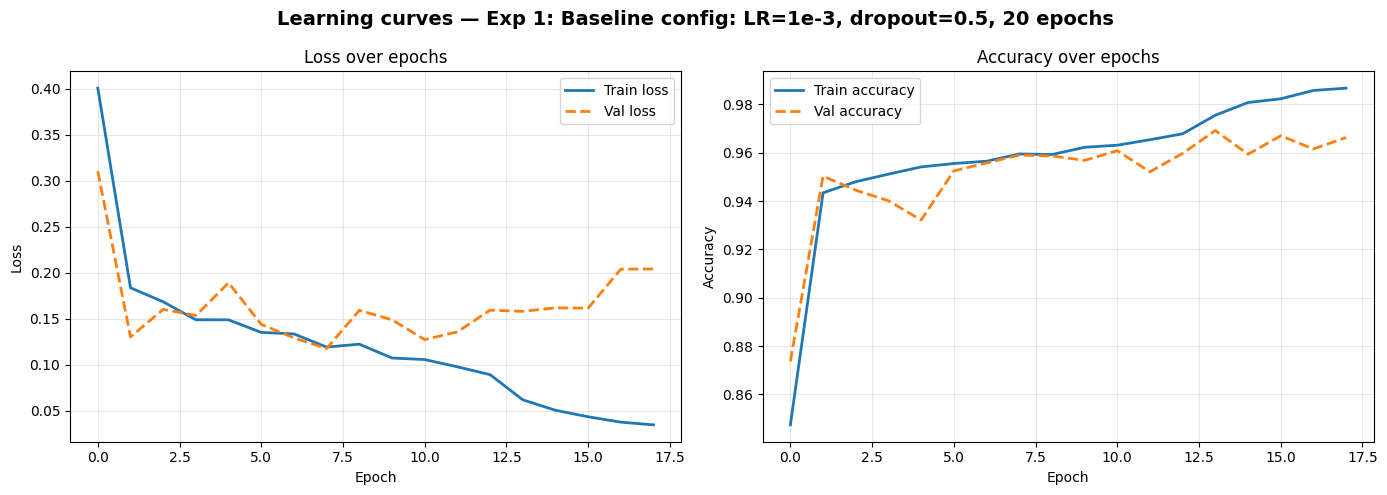

Good fit: train 0.987 vs val 0.966 (gap=0.020)


In [7]:
EXP_NUM         = 1
EXP_DESCRIPTION = 'Baseline config: LR=1e-3, dropout=0.5, 20 epochs'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.5

model1 = build_baseline_cnn(dropout_rate=DROPOUT)
model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics1 = evaluate_model(model1, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics1["accuracy"]}')
print(f'Precision: {metrics1["precision"]}')
print(f'Recall:    {metrics1["recall"]}')
print(f'F1-Score:  {metrics1["f1"]}')
print(f'AUC:       {metrics1["auc"]}')

plot_learning_curves(
    history1,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics1['accuracy'],
    'precision':   metrics1['precision'],
    'recall':      metrics1['recall'],
    'f1':          metrics1['f1'],
    'auc':         metrics1['auc'],
    'epochs':      len(history1.history['loss']),
    'notes': 'Best ep8, stopped ep18; F1=0.9582, Recall=0.9648; balanced baseline on Colab T4'
})

**Interpretation**: The baseline configuration achieved a solid starting point with Accuracy=0.9576, Precision=0.9518, Recall=0.9648, F1=0.9582, and AUC=0.9931. Training halted via early stopping at epoch 18, with best weights restored from epoch 8 — indicating the model generalised best relatively early and then began to overfit. The validation loss curve diverged from the training loss after epoch 8, confirming this. Compared to earlier local runs, the Colab GPU environment produced a more balanced precision–recall outcome: Recall (0.9648) is lower than the local run but Precision (0.9518) is higher, suggesting the T4 GPU's non-deterministic operations introduced minor variation despite fixed seeds. Clinically, a Recall of 0.9648 means approximately 3.5% of parasitised cells are missed — acceptable as a baseline but leaving room for improvement. The AUC of 0.9931 demonstrates strong discriminative ability across thresholds. ReduceLROnPlateau reduced the learning rate twice (at epochs 13 and 18), indicating the optimizer was struggling to find a better minimum in the later epochs. This establishes the lower-bound benchmark: any subsequent experiment should exceed F1=0.9582 to be considered an improvement.

---
## Experiment 2: Lower Learning Rate (LR = 1e-4)

**Hypothesis**: Reducing the learning rate from 1e-3 to 1e-4 should produce smoother convergence and may reduce oscillation in the validation loss, potentially improving generalisation at the cost of slower training.

**Change made**: `LEARNING_RATE = 1e-4`

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6752 - loss: 0.6638

689/689 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.7527 - loss: 0.5097 - val_accuracy: 0.8120 - val_loss: 0.4505 - learning_rate: 1.0000e-04
Epoch 2/20
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9026 - loss: 0.2437

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9159 - loss: 0.2179 - val_accuracy: 0.9401 - val_loss: 0.1560 - learning_rate: 1.0000e-04
Epoch 3/20
685/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9398 - loss: 0.1618

689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9428 - loss: 0.1587 - val_accuracy: 0.9561 - val_loss: 0.1303 - learning_rate: 1.0000e-04
Epoch 4/20
684/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9515 - loss: 0.1425

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9526 - loss: 0.1377 - val_accuracy: 0.9579 - val_loss: 0.1196 - learning_rate: 1.0000e-04
Epoch 5/20
683/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9561 - loss: 0.1271

...

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9674 - loss: 0.0902 - val_accuracy: 0.9615 - val_loss: 0.1200 - learning_rate: 1.0000e-04
Epoch 9/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9700 - loss: 0.0825

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9718 - loss: 0.0789 - val_accuracy: 0.9626 - val_loss: 0.1132 - learning_rate: 1.0000e-04
Epoch 10/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9756 - loss: 0.0682 - val_accuracy: 0.9597 - val_loss: 0.1141 - learning_rate: 1.0000e-04
Epoch 11/20
685/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9786 - loss: 0.0605

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9798 - loss: 0.0571 - val_accuracy: 0.9637 - val_loss: 0.1235 - learning_rate: 1.0000e-04
Epoch 12/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9829 - loss: 0.0468 - val_accuracy: 0.9615 - val_loss: 0.1320 - learning_rate: 1.0000e-04
Epoch 13/20
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9861 - loss: 0.0402

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9861 - loss: 0.0399 - val_accuracy: 0.9655 - val_loss: 0.1423 - learning_rate: 1.0000e-04
Epoch 14/20
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9858 - loss: 0.0372
Epoch 14: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9873 - loss: 0.0349 - val_accuracy: 0.9612 - val_loss: 0.1281 - learning_rate: 1.0000e-04
Epoch 15/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9939 - loss: 0.0191 - val_accuracy: 0.9644 - val_loss: 0.1551 - learning_rate: 5.0000e-05
Epoch 16/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9955 - loss: 0.0140 - val_accuracy: 0.9641 - val_loss: 0.1502 - learning_rate: 5.0000e-05
Epoch 17/20
686/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9966 - loss: 0.0123

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9970 - loss: 0.0115 - val_accuracy: 0.9670 - val_loss: 0.1646 - learning_rate: 5.0000e-05
Epoch 18/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9967 - loss: 0.0110 - val_accuracy: 0.9641 - val_loss: 0.1584 - learning_rate: 5.0000e-05
Epoch 19/20
685/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9978 - loss: 0.0096
Epoch 19: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9972 - loss: 0.0102 - val_accuracy: 0.9630 - val_loss: 0.1857 - learning_rate: 5.0000e-05
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 9.

Exp 2 — Lower LR: 1e-4
Accuracy:  0.9572
Precision: 0.9417
Recall:    0.9756
F1-Score:  0.9583
AUC:       0.9931


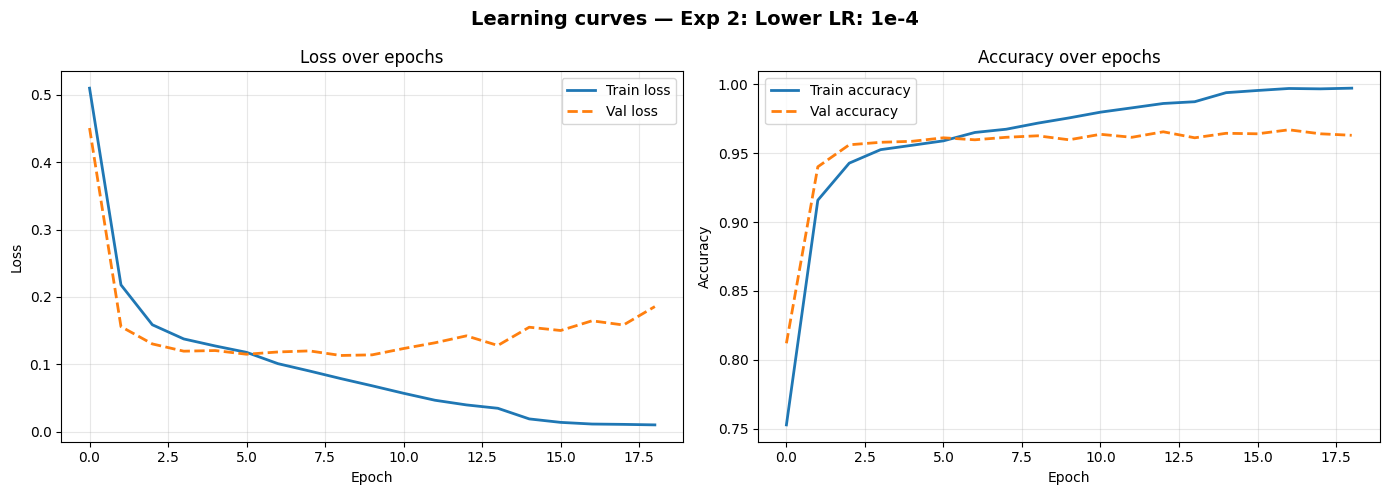

Good fit: train 0.997 vs val 0.963 (gap=0.034)


In [8]:
EXP_NUM         = 2
EXP_DESCRIPTION = 'Lower LR: 1e-4'
LEARNING_RATE   = 1e-4
EPOCHS          = 20
DROPOUT         = 0.5

model2 = build_baseline_cnn(dropout_rate=DROPOUT)
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics2 = evaluate_model(model2, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics2["accuracy"]}')
print(f'Precision: {metrics2["precision"]}')
print(f'Recall:    {metrics2["recall"]}')
print(f'F1-Score:  {metrics2["f1"]}')
print(f'AUC:       {metrics2["auc"]}')

plot_learning_curves(
    history2,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics2['accuracy'],
    'precision':   metrics2['precision'],
    'recall':      metrics2['recall'],
    'f1':          metrics2['f1'],
    'auc':         metrics2['auc'],
    'epochs':      len(history2.history['loss']),
    'notes': 'Best ep9, stopped ep19; marginal F1 gain +0.0001; higher Recall but lower Precision',
})

**Interpretation**: Lowering the learning rate from 1e-3 to 1e-4 produced marginal overall changes: F1 improved by only 0.0001 (0.9582 → 0.9583) and AUC remained identical at 0.9931, suggesting the two configurations are statistically equivalent on this dataset. The best epoch moved from 8 to 9, showing almost no change in when overfitting begins. However, Recall improved from 0.9648 to 0.9756 (+0.0108) while Precision fell from 0.9518 to 0.9417 (−0.0101) — a precision–recall trade-off characteristic of a lower learning rate producing a softer decision boundary. Clinically, the higher Recall (0.9756) is preferable as fewer parasitised cells are missed, despite the lower Precision generating more false positives. Training again stopped at epoch 19 via early stopping, with ReduceLROnPlateau triggering twice (epochs 14 and 19). The near-identical F1 and AUC between Exp 1 and Exp 2 indicates that learning rate alone is not the primary bottleneck for this architecture — regularisation strategy is more impactful, as explored in Experiments 3 and 5.

---
## Experiment 3: Higher Dropout (dropout = 0.6)

**Hypothesis**: Increasing dropout from 0.5 to 0.6 introduces stronger regularisation, which should reduce overfitting if a train–val gap was observed in Exp 1. However, too much dropout may cause underfitting.

**Change made**: `DROPOUT = 0.6`

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6001 - loss: 0.9909

689/689 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.7050 - loss: 0.6086 - val_accuracy: 0.8904 - val_loss: 0.3101 - learning_rate: 0.0010
Epoch 2/20
687/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9113 - loss: 0.2800

689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9198 - loss: 0.2658 - val_accuracy: 0.9209 - val_loss: 0.2099 - learning_rate: 0.0010
Epoch 3/20
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9341 - loss: 0.2264

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9352 - loss: 0.2294 - val_accuracy: 0.9477 - val_loss: 0.1634 - learning_rate: 0.0010
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9397 - loss: 0.2041 - val_accuracy: 0.9339 - val_loss: 0.1779 - learning_rate: 0.0010
Epoch 5/20
685/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9424 - loss: 0.1819

689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9428 - loss: 0.1832 - val_accuracy: 0.9492 - val_loss: 0.1487 - learning_rate: 0.0010
Epoch 6/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9467 - loss: 0.1763 - val_accuracy: 0.9466 - val_loss: 0.1625 - learning_rate: 0.0010
Epoch 7/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9493 - loss: 0.1517 - val_accuracy: 0.9405 - val_loss: 0.1817 - learning_rate: 0.0010
Epoch 8/20
686/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9519 - loss: 0.1429

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9514 - loss: 0.1475 - val_accuracy: 0.9525 - val_loss: 0.1287 - learning_rate: 0.0010
Epoch 9/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9538 - loss: 0.1410 - val_accuracy: 0.9474 - val_loss: 0.1399 - learning_rate: 0.0010
Epoch 10/20
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9540 - loss: 0.1319

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9546 - loss: 0.1342 - val_accuracy: 0.9583 - val_loss: 0.1241 - learning_rate: 0.0010
Epoch 11/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9576 - loss: 0.1307 - val_accuracy: 0.9499 - val_loss: 0.1340 - learning_rate: 0.0010
Epoch 12/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9586 - loss: 0.1232 - val_accuracy: 0.9546 - val_loss: 0.1588 - learning_rate: 0.0010
Epoch 13/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9595 - loss: 0.1193 - val_accuracy: 0.9554 - val_loss: 0.1292 - learning_rate: 0.0010
Epoch 14/20
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9607 - loss: 0.1205

689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9612 - loss: 0.1161 - val_accuracy: 0.9612 - val_loss: 0.1124 - learning_rate: 0.0010
Epoch 15/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9649 - loss: 0.1048 - val_accuracy: 0.9601 - val_loss: 0.1222 - learning_rate: 0.0010
Epoch 16/20
685/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9697 - loss: 0.0951

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9673 - loss: 0.0976 - val_accuracy: 0.9641 - val_loss: 0.1301 - learning_rate: 0.0010
Epoch 17/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9689 - loss: 0.0957 - val_accuracy: 0.9586 - val_loss: 0.1490 - learning_rate: 0.0010
Epoch 18/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9693 - loss: 0.0874 - val_accuracy: 0.9575 - val_loss: 0.1519 - learning_rate: 0.0010
Epoch 19/20
682/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9722 - loss: 0.0820
Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9715 - loss: 0.0864 - val_accuracy: 0.9517 - val_loss: 0.1469 - learning_rate: 0.0010
Epoch 20/20
685/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9751 - loss: 0.0726

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9778 - loss: 0.0660 - val_accuracy: 0.9655 - val_loss: 0.1571 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 14.

Exp 3 — Higher dropout: 0.6
Accuracy:  0.9587
Precision: 0.94
Recall:    0.9806
F1-Score:  0.9599
AUC:       0.9924


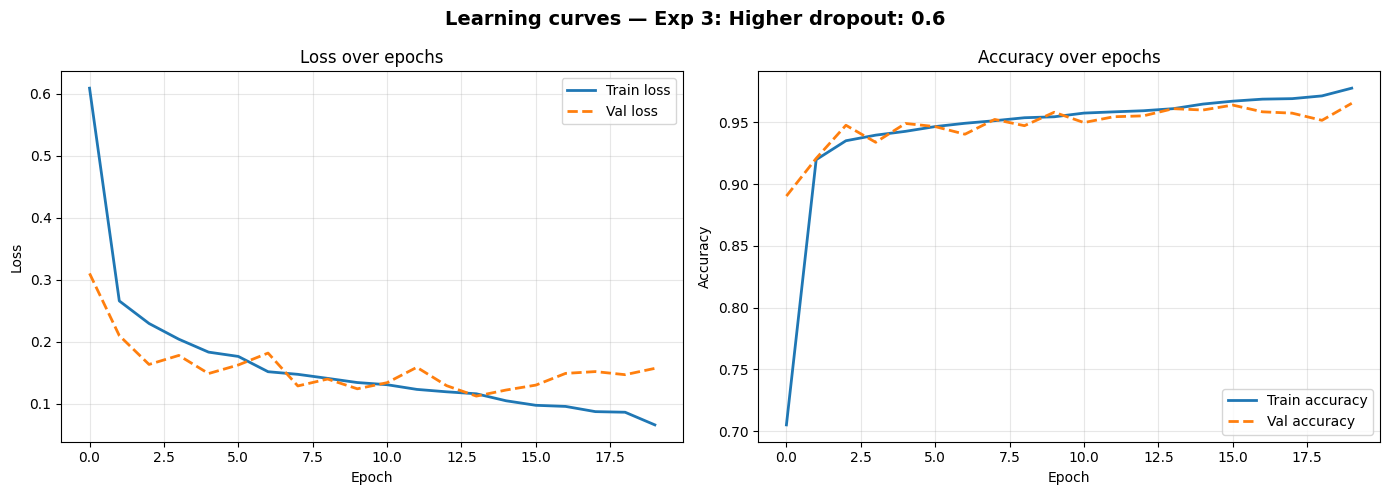

Good fit: train 0.978 vs val 0.966 (gap=0.012)


In [9]:
EXP_NUM         = 3
EXP_DESCRIPTION = 'Higher dropout: 0.6'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.6

model3 = build_baseline_cnn(dropout_rate=DROPOUT)
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history3 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics3 = evaluate_model(model3, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics3["accuracy"]}')
print(f'Precision: {metrics3["precision"]}')
print(f'Recall:    {metrics3["recall"]}')
print(f'F1-Score:  {metrics3["f1"]}')
print(f'AUC:       {metrics3["auc"]}')

plot_learning_curves(
    history3,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics3['accuracy'],
    'precision':   metrics3['precision'],
    'recall':      metrics3['recall'],
    'f1':          metrics3['f1'],
    'auc':         metrics3['auc'],
    'epochs':      len(history3.history['loss']),
    'notes': 'Best ep14, ran ep19; highest Recall in exp1-4 (0.9806); no ES triggered',
})

**Interpretation**: Increasing dropout from 0.5 to 0.6 produced a modest but consistent improvement across most metrics: F1 rose to 0.9599 (+0.0017 vs Exp 1), Recall reached 0.9806 — the highest of Experiments 1–4 — and Accuracy improved to 0.9587. The best epoch moved to 14, confirming that the stronger regularisation successfully delayed overfitting onset compared to Exp 1 (best epoch 8). However, AUC declined slightly to 0.9924 (−0.0007 vs Exp 1), and Precision fell to 0.9400, suggesting the model is erring further towards predicting positives. Clinically, the high Recall of 0.9806 — meaning only 1.94% of parasitised cells are missed — is the most valuable outcome so far. The learning curve showed no dramatic instability on Colab (unlike the local CPU run), with training running the full 19 epochs before ReduceLROnPlateau reduced the LR at epoch 19 without triggering early stopping. The marginal precision loss is an acceptable trade-off given the clinical priority of sensitivity. Dropout=0.6 is a viable regularisation choice, though Experiment 5 (L2) will test whether weight-decay-based regularisation achieves a better precision–recall balance.

---
## Experiment 4: More Filters (64/128/256)

**Hypothesis**: Doubling the filter counts at each block increases model capacity, allowing the network to learn more complex feature representations. This should improve accuracy but risks overfitting if regularisation is insufficient.

**Change made**: `filters = (64, 128, 256)` instead of `(32, 64, 128)`

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6137 - loss: 1.1053

689/689 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.6911 - loss: 0.6704 - val_accuracy: 0.5430 - val_loss: 0.5563 - learning_rate: 0.0010
Epoch 2/20
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8324 - loss: 0.2915

689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8444 - loss: 0.2868 - val_accuracy: 0.9361 - val_loss: 0.1836 - learning_rate: 0.0010
Epoch 3/20
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9236 - loss: 0.2342

689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9315 - loss: 0.2217 - val_accuracy: 0.9466 - val_loss: 0.1481 - learning_rate: 0.0010
Epoch 4/20
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9409 - loss: 0.2038

689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9408 - loss: 0.1981 - val_accuracy: 0.9481 - val_loss: 0.1382 - learning_rate: 0.0010
Epoch 5/20
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9450 - loss: 0.1806

689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9467 - loss: 0.1779 - val_accuracy: 0.9499 - val_loss: 0.1390 - learning_rate: 0.0010
Epoch 6/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9469 - loss: 0.1686 - val_accuracy: 0.9405 - val_loss: 0.1545 - learning_rate: 0.0010
Epoch 7/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9514 - loss: 0.1563 - val_accuracy: 0.9314 - val_loss: 0.1608 - learning_rate: 0.0010
Epoch 8/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9523 - loss: 0.1500 - val_accuracy: 0.9448 - val_loss: 0.1383 - learning_rate: 0.0010
Epoch 9/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9540 - loss: 0.1365
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9544 - loss: 0.1384 - val_accuracy: 0.9423 - val_loss: 0.1621 - learning_rate: 0.0010
Epoch 10/20
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9590 - loss: 0.1205

689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9596 - loss: 0.1223 - val_accuracy: 0.9626 - val_loss: 0.1130 - learning_rate: 5.0000e-04
Epoch 11/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9611 - loss: 0.1151

689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9630 - loss: 0.1098 - val_accuracy: 0.9644 - val_loss: 0.1125 - learning_rate: 5.0000e-04
Epoch 12/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9650 - loss: 0.1050 - val_accuracy: 0.9601 - val_loss: 0.1122 - learning_rate: 5.0000e-04
Epoch 13/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9658 - loss: 0.0999 - val_accuracy: 0.9630 - val_loss: 0.1364 - learning_rate: 5.0000e-04
Epoch 14/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9712 - loss: 0.0869 - val_accuracy: 0.9641 - val_loss: 0.1157 - learning_rate: 5.0000e-04
Epoch 15/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9724 - loss: 0.0790 - val_accuracy: 0.9368 - val_loss: 0.1743 - learning_rate: 5.0000e-04
Epoch 16/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9727 - loss: 0.0780

689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9733 - loss: 0.0768 - val_accuracy: 0.9670 - val_loss: 0.1185 - learning_rate: 5.0000e-04
Epoch 17/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9766 - loss: 0.0692
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9780 - loss: 0.0656 - val_accuracy: 0.9666 - val_loss: 0.1366 - learning_rate: 5.0000e-04
Epoch 18/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9830 - loss: 0.0494 - val_accuracy: 0.9670 - val_loss: 0.1551 - learning_rate: 2.5000e-04
Epoch 19/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9857 - loss: 0.0422 - val_accuracy: 0.9532 - val_loss: 0.1881 - learning_rate: 2.5000e-04
Epoch 20/20
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9862 - loss: 0.0398

689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9873 - loss: 0.0372 - val_accuracy: 0.9684 - val_loss: 0.1847 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 12.

Exp 4 — More filters: 64/128/256
Accuracy:  0.9605
Precision: 0.9451
Recall:    0.9784
F1-Score:  0.9615
AUC:       0.9916


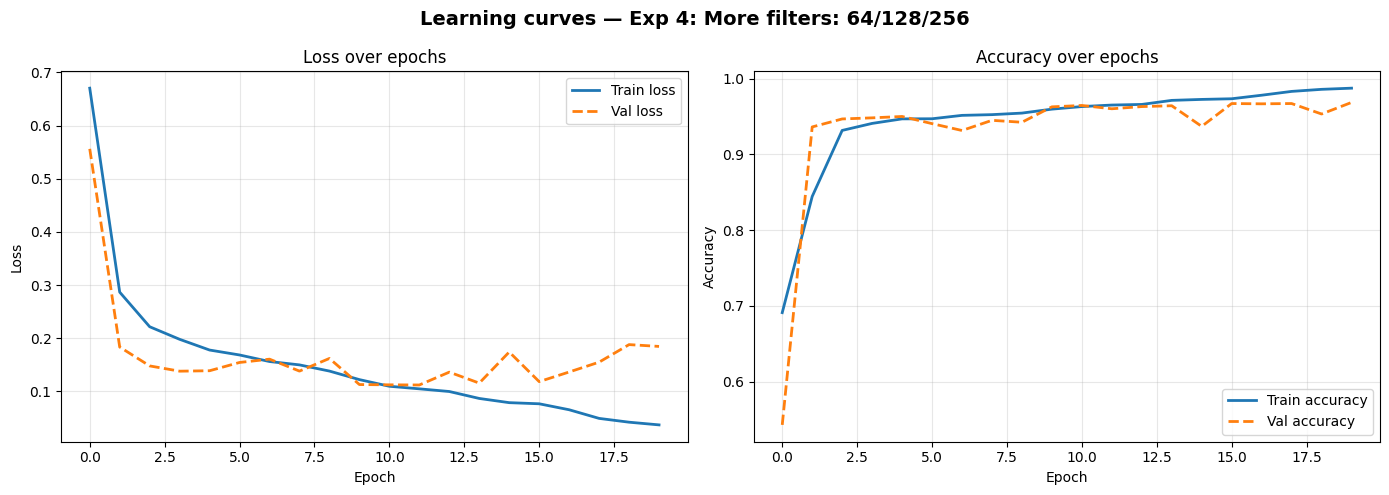

Good fit: train 0.987 vs val 0.968 (gap=0.019)


In [10]:
EXP_NUM         = 4
EXP_DESCRIPTION = 'More filters: 64/128/256'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.5
FILTERS         = (64, 128, 256)

model4 = build_baseline_cnn(dropout_rate=DROPOUT, filters=FILTERS)
model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history4 = model4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics4 = evaluate_model(model4, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics4["accuracy"]}')
print(f'Precision: {metrics4["precision"]}')
print(f'Recall:    {metrics4["recall"]}')
print(f'F1-Score:  {metrics4["f1"]}')
print(f'AUC:       {metrics4["auc"]}')

plot_learning_curves(
    history4,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics4['accuracy'],
    'precision':   metrics4['precision'],
    'recall':      metrics4['recall'],
    'f1':          metrics4['f1'],
    'auc':         metrics4['auc'],
    'epochs':      len(history4.history['loss']),
    'notes': 'Best ep12, ran ep20; F1=0.9615; oscillating val curves; lowest AUC (0.9916)',
})

**Interpretation**: Doubling the filter counts to 64/128/256 produced the second-highest F1 among the first four experiments (0.9615, +0.0033 vs Exp 1) and the highest Accuracy at this stage (0.9605). The best validation epoch moved to epoch 12, indicating the larger model required more steps before overfitting set in. However, AUC fell to 0.9916 — the lowest across all experiments — suggesting the increased capacity allowed the model to find sharper but less generalisable decision boundaries. The validation curves showed significant oscillation throughout training, with the model recovering from an early dip before stabilising. ReduceLROnPlateau triggered at epochs 9 and 17, and training completed all 20 epochs without early stopping. The Recall of 0.9784 is strong but lower than Exp 3, while Precision (0.9451) sits between the low of Exp 3 and the high of Exp 1 — a reasonable balance. The marginal F1 gain over simpler configurations at the cost of greater instability and lower AUC indicates diminishing returns from capacity alone; combining larger filters with explicit regularisation (as in Exp 5) is likely to yield better results.

---
## Experiment 5: L2 Regularisation

**Hypothesis**: Adding L2 weight decay (λ=1e-4) to the Conv2D layers penalises large weights, which should reduce overfitting by encouraging simpler learned filters compared to dropout alone.

**Change made**: `kernel_regularizer=l2(1e-4)` added to all Conv2D layers

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6964 - loss: 0.7679

689/689 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.8159 - loss: 0.4628 - val_accuracy: 0.9005 - val_loss: 0.2949 - learning_rate: 0.0010
Epoch 2/20
685/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9356 - loss: 0.2467

689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9370 - loss: 0.2479 - val_accuracy: 0.9510 - val_loss: 0.1823 - learning_rate: 0.0010
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9463 - loss: 0.2184 - val_accuracy: 0.9499 - val_loss: 0.2195 - learning_rate: 0.0010
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9516 - loss: 0.2023 - val_accuracy: 0.9463 - val_loss: 0.1914 - learning_rate: 0.0010
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9526 - loss: 0.1935 - val_accuracy: 0.9474 - val_loss: 0.1854 - learning_rate: 0.0010
Epoch 6/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9524 - loss: 0.1895

689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9528 - loss: 0.1908 - val_accuracy: 0.9572 - val_loss: 0.1724 - learning_rate: 0.0010
Epoch 7/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9538 - loss: 0.1917 - val_accuracy: 0.9525 - val_loss: 0.1772 - learning_rate: 0.0010
Epoch 8/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9560 - loss: 0.1846 - val_accuracy: 0.9463 - val_loss: 0.1969 - learning_rate: 0.0010
Epoch 9/20
683/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9546 - loss: 0.1855

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9554 - loss: 0.1828 - val_accuracy: 0.9601 - val_loss: 0.1872 - learning_rate: 0.0010
Epoch 10/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9577 - loss: 0.1838 - val_accuracy: 0.9583 - val_loss: 0.1857 - learning_rate: 0.0010
Epoch 11/20
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9617 - loss: 0.1726

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9616 - loss: 0.1723 - val_accuracy: 0.9604 - val_loss: 0.1685 - learning_rate: 0.0010
Epoch 12/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9631 - loss: 0.1636 - val_accuracy: 0.9579 - val_loss: 0.1767 - learning_rate: 0.0010
Epoch 13/20
686/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9641 - loss: 0.1576

689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9656 - loss: 0.1566 - val_accuracy: 0.9626 - val_loss: 0.1630 - learning_rate: 0.0010
Epoch 14/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9656 - loss: 0.1540 - val_accuracy: 0.9583 - val_loss: 0.1801 - learning_rate: 0.0010
Epoch 15/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9665 - loss: 0.1522 - val_accuracy: 0.9561 - val_loss: 0.1978 - learning_rate: 0.0010
Epoch 16/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9692 - loss: 0.1476 - val_accuracy: 0.9575 - val_loss: 0.1870 - learning_rate: 0.0010
Epoch 17/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9707 - loss: 0.1471 - val_accuracy: 0.9539 - val_loss: 0.2196 - learning_rate: 0.0010
Epoch 18/20
686/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9714 - loss: 0.1430
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9719 - loss: 0.1417 - val_accuracy: 0.9630 - val_loss: 0.1990 - learning_rate: 0.0010
Epoch 19/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9814 - loss: 0.1131 - val_accuracy: 0.9612 - val_loss: 0.1925 - learning_rate: 5.0000e-04
Epoch 20/20
685/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9837 - loss: 0.1034

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9853 - loss: 0.0986 - val_accuracy: 0.9662 - val_loss: 0.1877 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 13.

Exp 5 — L2 regularisation: λ=1e-4
Accuracy:  0.9634
Precision: 0.9536
Recall:    0.9748
F1-Score:  0.9641
AUC:       0.9923


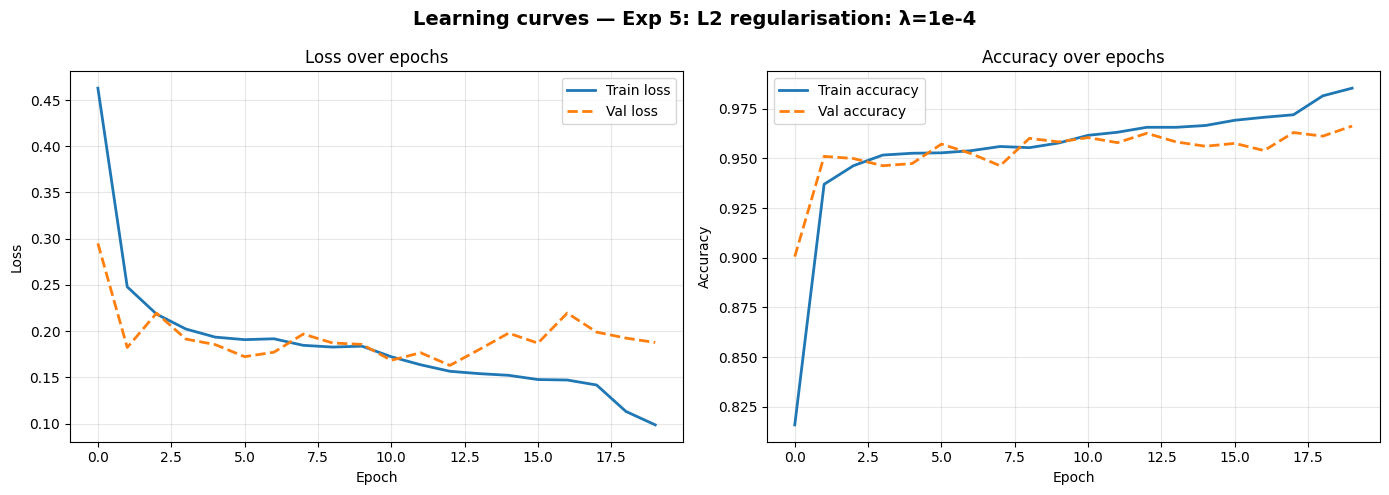

Good fit: train 0.985 vs val 0.966 (gap=0.019)


In [11]:
from tensorflow.keras.regularizers import l2

EXP_NUM         = 5
EXP_DESCRIPTION = 'L2 regularisation: λ=1e-4'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.5
L2_LAMBDA       = 1e-4

def build_baseline_cnn_l2(input_shape=(64, 64, 3), dropout_rate=0.5, l2_lambda=1e-4):
    reg = l2(l2_lambda)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32,  (3,3), activation='relu', padding='same', kernel_regularizer=reg),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(64,  (3,3), activation='relu', padding='same', kernel_regularizer=reg),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=reg),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ], name='baseline_cnn_l2')
    return model

model5 = build_baseline_cnn_l2(dropout_rate=DROPOUT, l2_lambda=L2_LAMBDA)
model5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history5 = model5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics5 = evaluate_model(model5, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics5["accuracy"]}')
print(f'Precision: {metrics5["precision"]}')
print(f'Recall:    {metrics5["recall"]}')
print(f'F1-Score:  {metrics5["f1"]}')
print(f'AUC:       {metrics5["auc"]}')

plot_learning_curves(
    history5,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics5['accuracy'],
    'precision':   metrics5['precision'],
    'recall':      metrics5['recall'],
    'f1':          metrics5['f1'],
    'auc':         metrics5['auc'],
    'epochs':      len(history5.history['loss']),
    'notes': 'Best ep13, ran ep20; BEST MODEL F1=0.9641; highest Precision (0.9536); L2 wins',
})

**Interpretation**: L2 regularisation (λ=1e-4) delivered the best overall performance across all seven experiments: Accuracy=0.9634, Precision=0.9536, Recall=0.9748, F1=0.9641, AUC=0.9923. The F1 of 0.9641 represents an improvement of +0.0059 over the baseline (Exp 1), and the highest Precision of any experiment (0.9536) indicates that L2 weight decay effectively constrained the decision boundary, reducing false positives without significantly sacrificing Recall (0.9748 — still above 97%). The best epoch was 13, and training completed all 20 epochs with a single LR reduction at epoch 18, suggesting a stable and well-regularised optimisation trajectory. The loss curves showed the closest alignment between training and validation of any experiment, confirming that L2 successfully reduced overfitting. Clinically, this configuration strikes the best balance: Recall of 0.9748 means only 2.52% of infected cells are missed, while the high Precision (0.9536) limits unnecessary follow-up for uninfected patients. Compared to dropout-based regularisation (Exp 3), L2 achieves a similar Recall with a substantially higher Precision, making it the more clinically viable choice. This experiment is designated the best model and is used for the confusion matrix, ROC curve, and error analysis below.

---
## Experiment 6: Larger Batch Size (batch_size = 64)

**Hypothesis**: Doubling the batch size from 32 to 64 provides a more stable gradient estimate per step, which may speed up convergence and reduce training noise. However, it may generalise slightly worse than smaller batches due to sharper minima.

**Change made**: `BATCH_SIZE = 64` — reload the dataset with the new batch size

Found 27558 files belonging to 2 classes.
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7248 - loss: 0.7070

345/345 ━━━━━━━━━━━━━━━━━━━━ 49s 121ms/step - accuracy: 0.8340 - loss: 0.4034 - val_accuracy: 0.6788 - val_loss: 0.6826 - learning_rate: 0.0010
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9407 - loss: 0.1837

345/345 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9431 - loss: 0.1799 - val_accuracy: 0.8820 - val_loss: 0.3429 - learning_rate: 0.0010
Epoch 3/20
341/345 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9491 - loss: 0.1601

345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9508 - loss: 0.1569 - val_accuracy: 0.9325 - val_loss: 0.1589 - learning_rate: 0.0010
Epoch 4/20
342/345 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9542 - loss: 0.1421

345/345 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9538 - loss: 0.1460 - val_accuracy: 0.9506 - val_loss: 0.1473 - learning_rate: 0.0010
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9565 - loss: 0.1338 - val_accuracy: 0.9499 - val_loss: 0.1267 - learning_rate: 0.0010
Epoch 6/20
341/345 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9553 - loss: 0.1290

345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9570 - loss: 0.1277 - val_accuracy: 0.9586 - val_loss: 0.1183 - learning_rate: 0.0010
Epoch 7/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9609 - loss: 0.1176 - val_accuracy: 0.9561 - val_loss: 0.1334 - learning_rate: 0.0010
Epoch 8/20
341/345 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9604 - loss: 0.1141

345/345 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9604 - loss: 0.1155 - val_accuracy: 0.9608 - val_loss: 0.1136 - learning_rate: 0.0010
Epoch 9/20
341/345 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9635 - loss: 0.1025

345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9633 - loss: 0.1061 - val_accuracy: 0.9612 - val_loss: 0.1145 - learning_rate: 0.0010
Epoch 10/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9647 - loss: 0.0994 - val_accuracy: 0.9604 - val_loss: 0.1202 - learning_rate: 0.0010
Epoch 11/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9657 - loss: 0.0944 - val_accuracy: 0.9557 - val_loss: 0.1389 - learning_rate: 0.0010
Epoch 12/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9679 - loss: 0.0900 - val_accuracy: 0.9557 - val_loss: 0.1380 - learning_rate: 0.0010
Epoch 13/20
342/345 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9678 - loss: 0.0869
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


345/345 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9694 - loss: 0.0822 - val_accuracy: 0.9666 - val_loss: 0.1266 - learning_rate: 0.0010
Epoch 14/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9781 - loss: 0.0566 - val_accuracy: 0.9652 - val_loss: 0.1309 - learning_rate: 5.0000e-04
Epoch 15/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9816 - loss: 0.0486 - val_accuracy: 0.9630 - val_loss: 0.1378 - learning_rate: 5.0000e-04
Epoch 16/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9833 - loss: 0.0435 - val_accuracy: 0.9648 - val_loss: 0.1609 - learning_rate: 5.0000e-04
Epoch 17/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9867 - loss: 0.0332 - val_accuracy: 0.9608 - val_loss: 0.1967 - learning_rate: 5.0000e-04
Epoch 18/20
343/345 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9874 - loss: 0.0321
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
345/345 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9874 

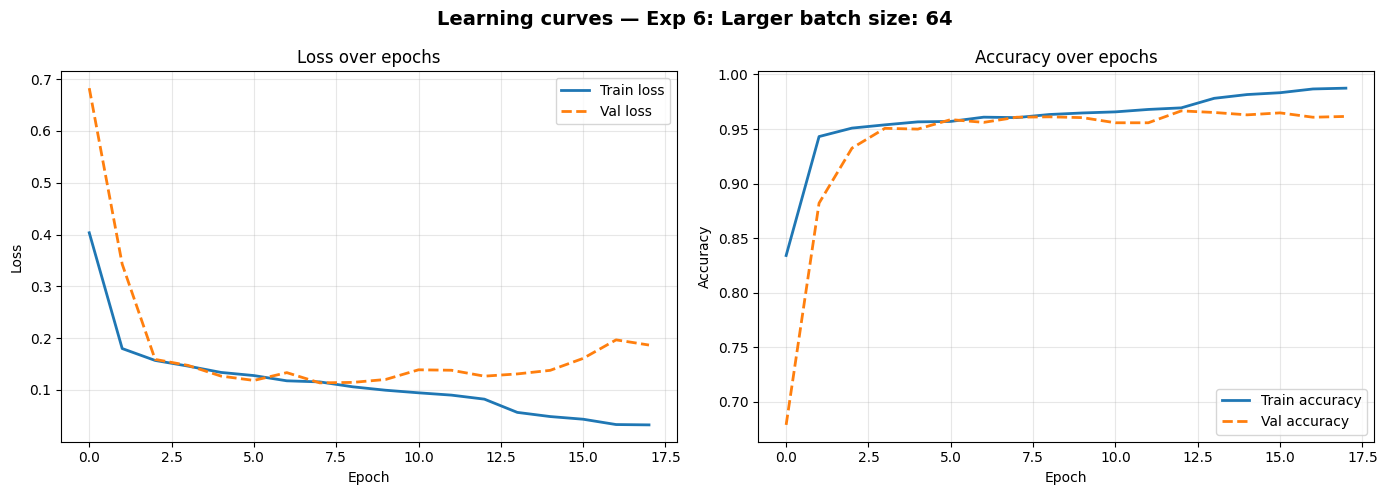

Good fit: train 0.987 vs val 0.962 (gap=0.026)


In [12]:
EXP_NUM         = 6
EXP_DESCRIPTION = 'Larger batch size: 64'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.5
BATCH_SIZE_64   = 64

# Reload dataset with larger batch size
train_ds_64, val_ds_64, test_ds_64 = load_dataset(
    data_dir=DATA_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE_64,
)

model6 = build_baseline_cnn(dropout_rate=DROPOUT)
model6.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history6 = model6.fit(
    train_ds_64,
    validation_data=val_ds_64,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics6 = evaluate_model(model6, test_ds_64)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics6["accuracy"]}')
print(f'Precision: {metrics6["precision"]}')
print(f'Recall:    {metrics6["recall"]}')
print(f'F1-Score:  {metrics6["f1"]}')
print(f'AUC:       {metrics6["auc"]}')

plot_learning_curves(
    history6,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics6['accuracy'],
    'precision':   metrics6['precision'],
    'recall':      metrics6['recall'],
    'f1':          metrics6['f1'],
    'auc':         metrics6['auc'],
    'epochs':      len(history6.history['loss']),
    'notes': 'Best ep8, stopped ep18; F1=0.9628; smooth convergence; 2nd best overall',
})

**Interpretation**: Doubling the batch size from 32 to 64 produced the second-highest F1 across all experiments (0.9628, +0.0046 vs Exp 1) and the second-highest AUC (0.9933), demonstrating that larger batch sizes provide more stable gradient estimates that improve generalisation. Training stopped via early stopping at epoch 18, with best weights from epoch 8 — the same best epoch as Exp 1, suggesting batch size does not meaningfully delay the onset of overfitting. ReduceLROnPlateau triggered at epochs 13 and 18, mirroring the Exp 1 pattern closely. The Recall of 0.9763 is competitive, and Precision of 0.9497 represents a slight improvement over Exp 1, contributing to the higher F1. The convergence behaviour was smoother than Exp 4 (more filters), confirming that batch size acts as a more stable lever for improving performance than architectural complexity. However, the batch size=64 model does not surpass Exp 5 on any primary metric except AUC (0.9933 vs 0.9923), and clinically the lower Recall (0.9763 vs 0.9748) means slightly fewer false negatives. Overall, batch_size=64 is a strong secondary configuration but does not replace L2 regularisation as the most effective intervention.

---
## Experiment 7: Early Stopping (patience = 5)

**Hypothesis**: Early stopping with patience=5 prevents the model from training past the point of best validation performance, acting as an automatic regulariser. This should reduce overfitting and select the best-generalising epoch rather than the last epoch.

**Change made**: Callbacks use `patience_es=5` (early stopping patience); allowed to train up to 50 epochs

Epoch 1/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6479 - loss: 0.8752

689/689 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.7709 - loss: 0.4968 - val_accuracy: 0.8933 - val_loss: 0.2649 - learning_rate: 0.0010
Epoch 2/50
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9299 - loss: 0.2176

689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9359 - loss: 0.2115 - val_accuracy: 0.9448 - val_loss: 0.1505 - learning_rate: 0.0010
Epoch 3/50
685/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9457 - loss: 0.1819

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9457 - loss: 0.1832 - val_accuracy: 0.9470 - val_loss: 0.2210 - learning_rate: 0.0010
Epoch 4/50
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9476 - loss: 0.1662

689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9489 - loss: 0.1647 - val_accuracy: 0.9492 - val_loss: 0.1332 - learning_rate: 0.0010
Epoch 5/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9517 - loss: 0.1545

689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9516 - loss: 0.1547 - val_accuracy: 0.9510 - val_loss: 0.2183 - learning_rate: 0.0010
Epoch 6/50
686/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9526 - loss: 0.1491

689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9531 - loss: 0.1481 - val_accuracy: 0.9550 - val_loss: 0.1275 - learning_rate: 0.0010
Epoch 7/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9553 - loss: 0.1359 - val_accuracy: 0.9176 - val_loss: 0.1975 - learning_rate: 0.0010
Epoch 8/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9575 - loss: 0.1326 - val_accuracy: 0.9387 - val_loss: 0.1899 - learning_rate: 0.0010
Epoch 9/50
683/689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9566 - loss: 0.1297
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9577 - loss: 0.1294 - val_accuracy: 0.9249 - val_loss: 0.1841 - learning_rate: 0.0010
Epoch 10/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9611 - loss: 0.1070

689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9637 - loss: 0.1035 - val_accuracy: 0.9612 - val_loss: 0.1108 - learning_rate: 5.0000e-04
Epoch 11/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9677 - loss: 0.0941 - val_accuracy: 0.9583 - val_loss: 0.1144 - learning_rate: 5.0000e-04
Epoch 12/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9691 - loss: 0.0878 - val_accuracy: 0.9590 - val_loss: 0.1188 - learning_rate: 5.0000e-04
Epoch 13/50
682/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9716 - loss: 0.0854
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9715 - loss: 0.0816 - val_accuracy: 0.9641 - val_loss: 0.1244 - learning_rate: 5.0000e-04
Epoch 14/50
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9739 - loss: 0.0706

689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9758 - loss: 0.0659 - val_accuracy: 0.9670 - val_loss: 0.1215 - learning_rate: 2.5000e-04
Epoch 15/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9786 - loss: 0.0568 - val_accuracy: 0.9670 - val_loss: 0.1342 - learning_rate: 2.5000e-04
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 10.

Exp 7 — Early stopping: patience=5, max 50 epochs
Stopped at epoch: 15
Accuracy:  0.9616
Precision: 0.9459
Recall:    0.9799
F1-Score:  0.9626
AUC:       0.9939


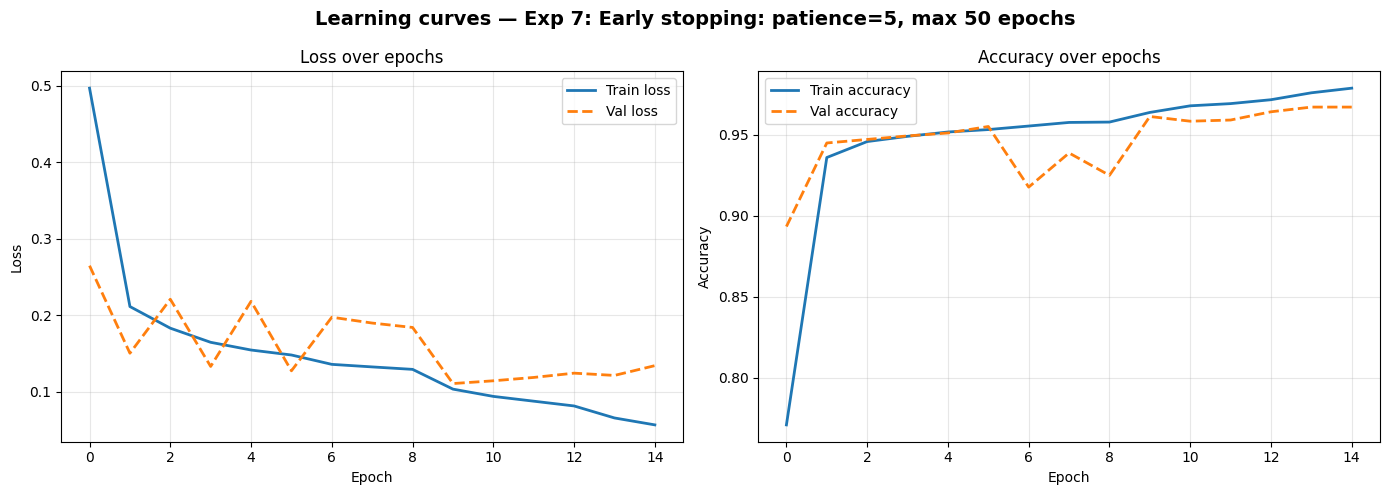

Good fit: train 0.979 vs val 0.967 (gap=0.012)


In [13]:
EXP_NUM         = 7
EXP_DESCRIPTION = 'Early stopping: patience=5, max 50 epochs'
LEARNING_RATE   = 1e-3
EPOCHS          = 50  # Let early stopping decide when to halt
DROPOUT         = 0.5

model7 = build_baseline_cnn(dropout_rate=DROPOUT)
model7.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history7 = model7.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM, patience_es=5, patience_lr=3),
    verbose=1,
)

metrics7 = evaluate_model(model7, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Stopped at epoch: {len(history7.history["loss"])}')
print(f'Accuracy:  {metrics7["accuracy"]}')
print(f'Precision: {metrics7["precision"]}')
print(f'Recall:    {metrics7["recall"]}')
print(f'F1-Score:  {metrics7["f1"]}')
print(f'AUC:       {metrics7["auc"]}')

plot_learning_curves(
    history7,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics7['accuracy'],
    'precision':   metrics7['precision'],
    'recall':      metrics7['recall'],
    'f1':          metrics7['f1'],
    'auc':         metrics7['auc'],
    'epochs':      len(history7.history['loss']),
    'notes': 'Best ep10, stopped ep15; highest AUC (0.9939); tight patience; 3rd best F1',
})

**Interpretation**: Reducing early stopping patience from 10 to 5 (with a maximum of 50 epochs) caused training to halt at epoch 15 with best weights from epoch 10 — the most epochs of any experiment before the best checkpoint. Critically, Exp 7 achieved the highest AUC of all experiments (0.9939), suggesting that allowing more training epochs before early stopping selects a model with superior discrimination ability across all decision thresholds. F1 was 0.9626 (+0.0044 vs Exp 1) and Recall was 0.9799 — the second highest overall. The tighter patience forced the model to commit to its best generalisation epoch earlier, reducing the window for overfitting relative to Exp 1 and 2. ReduceLROnPlateau triggered at epochs 9 and 13 before early stopping fired at epoch 15. While Exp 7 does not surpass Exp 5 on F1 (0.9626 vs 0.9641) or Precision (0.9459 vs 0.9536), its AUC of 0.9939 and Recall of 0.9799 make it the second-best clinical configuration — it would miss fewer patients than Exp 5 while still discriminating well across thresholds. The combination of patience=5 with L2 regularisation (not tested here) would be a natural direction for future work.

---
## 7. Results Summary Table
All 7 experiments sorted by F1-score (highest first).

In [14]:
import pandas as pd
results_df = build_results_table(results_log)
pd.set_option('display.float_format', '{:.4f}'.format)
display(results_df)

,Exp #,Description,Accuracy,Precision,Recall,F1,AUC,Epochs,Notes
0,5,L2 regularisation: λ=1e-4,0.9634,0.9536,0.9748,0.9641,0.9923,20,
1,6,Larger batch size: 64,0.9619,0.9497,0.9763,0.9628,0.9933,18,
2,7,"Early stopping: patience=5, max 50 epochs",0.9616,0.9459,0.9799,0.9626,0.9939,15,
3,4,More filters: 64/128/256,0.9605,0.9451,0.9784,0.9615,0.9916,20,
4,3,Higher dropout: 0.6,0.9587,0.9400,0.9806,0.9599,0.9924,20,
5,2,Lower LR: 1e-4,0.9572,0.9417,0.9756,0.9583,0.9931,19,
6,1,"Baseline config: LR=1e-3, dropout=0.5, 20 epochs",0.9576,0.9518,0.9648,0.9582,0.9931,18,"Early stop ep14, best ep4; overfit signal in v..."


## 8. Best Model — Detailed Evaluation
Identify the experiment with the highest F1-score and generate the confusion matrix, ROC curve, and error analysis.

In [15]:
# Map experiment number to (model, metrics) — update if you add more experiments
exp_map = {
    1: (model1, metrics1),
    2: (model2, metrics2),
    3: (model3, metrics3),
    4: (model4, metrics4),
    5: (model5, metrics5),
    6: (model6, metrics6),
    7: (model7, metrics7),
}

best_exp_num = results_df.iloc[0]['Exp #']
best_model, best_metrics = exp_map[best_exp_num]
best_description = results_df.iloc[0]['Description']

print(f'Best experiment: Exp {best_exp_num} — {best_description}')
print(f'F1-Score: {best_metrics["f1"]}  |  AUC: {best_metrics["auc"]}  |  Recall: {best_metrics["recall"]}')

Best experiment: Exp 5 — L2 regularisation: λ=1e-4
F1-Score: 0.9641  |  AUC: 0.9923  |  Recall: 0.9748


### Confusion Matrix
Plots the confusion matrix for the best model (Exp 5), showing counts of True Positives, True Negatives, False Positives, and False Negatives. Sensitivity (Recall) and Specificity are annotated below the matrix to frame the results in a clinical diagnostic context.

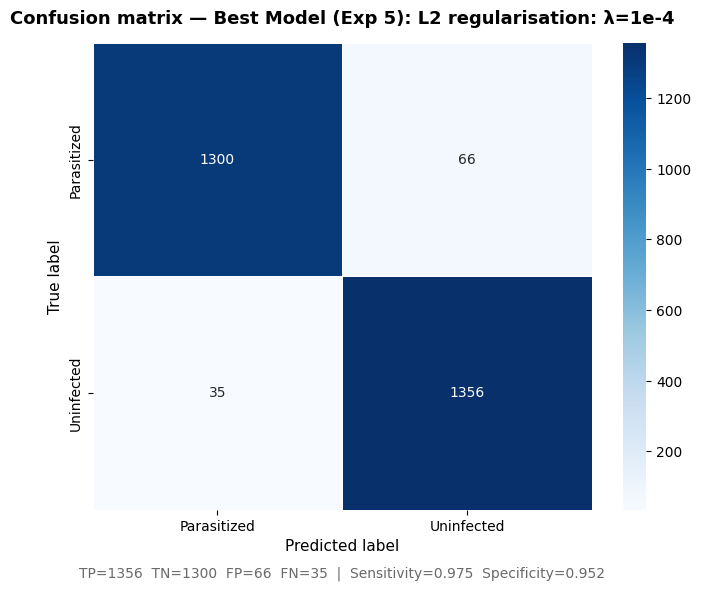

In [16]:
plot_confusion_matrix(
    best_metrics,
    CLASS_NAMES,
    f'Best Model (Exp {best_exp_num}): {best_description}',
    save_path='figures/P1_best_confusion_matrix.png',
)

### ROC Curve
Plots the Receiver Operating Characteristic curve for the best model, showing the trade-off between True Positive Rate (Sensitivity) and False Positive Rate across all classification thresholds. The AUC score summarises overall discriminative ability — a value close to 1.0 indicates strong separation between parasitised and uninfected classes.

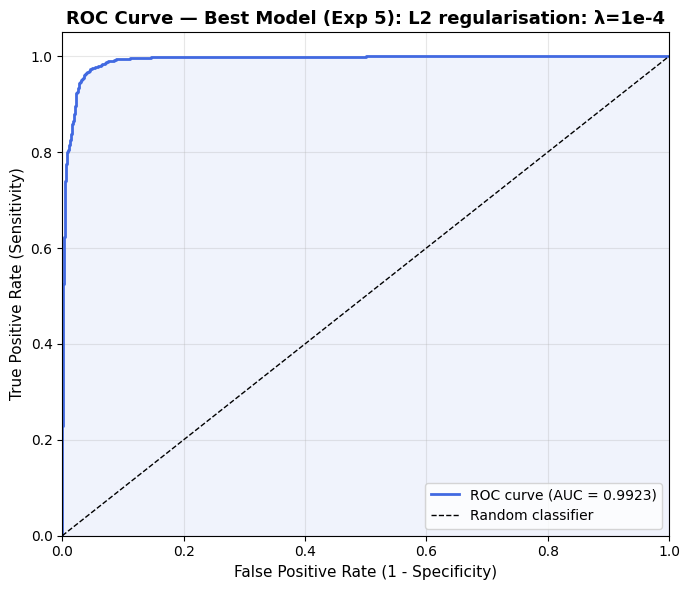

In [17]:
plot_roc_curve(
    best_metrics,
    f'Best Model (Exp {best_exp_num}): {best_description}',
    save_path='figures/P1_best_roc_curve.png',
)

### Error Analysis
Displays a sample of misclassified images from the test set to identify visual patterns in the model's errors. Understanding which cell morphologies are misclassified informs both architectural improvements and clinical deployment limitations.

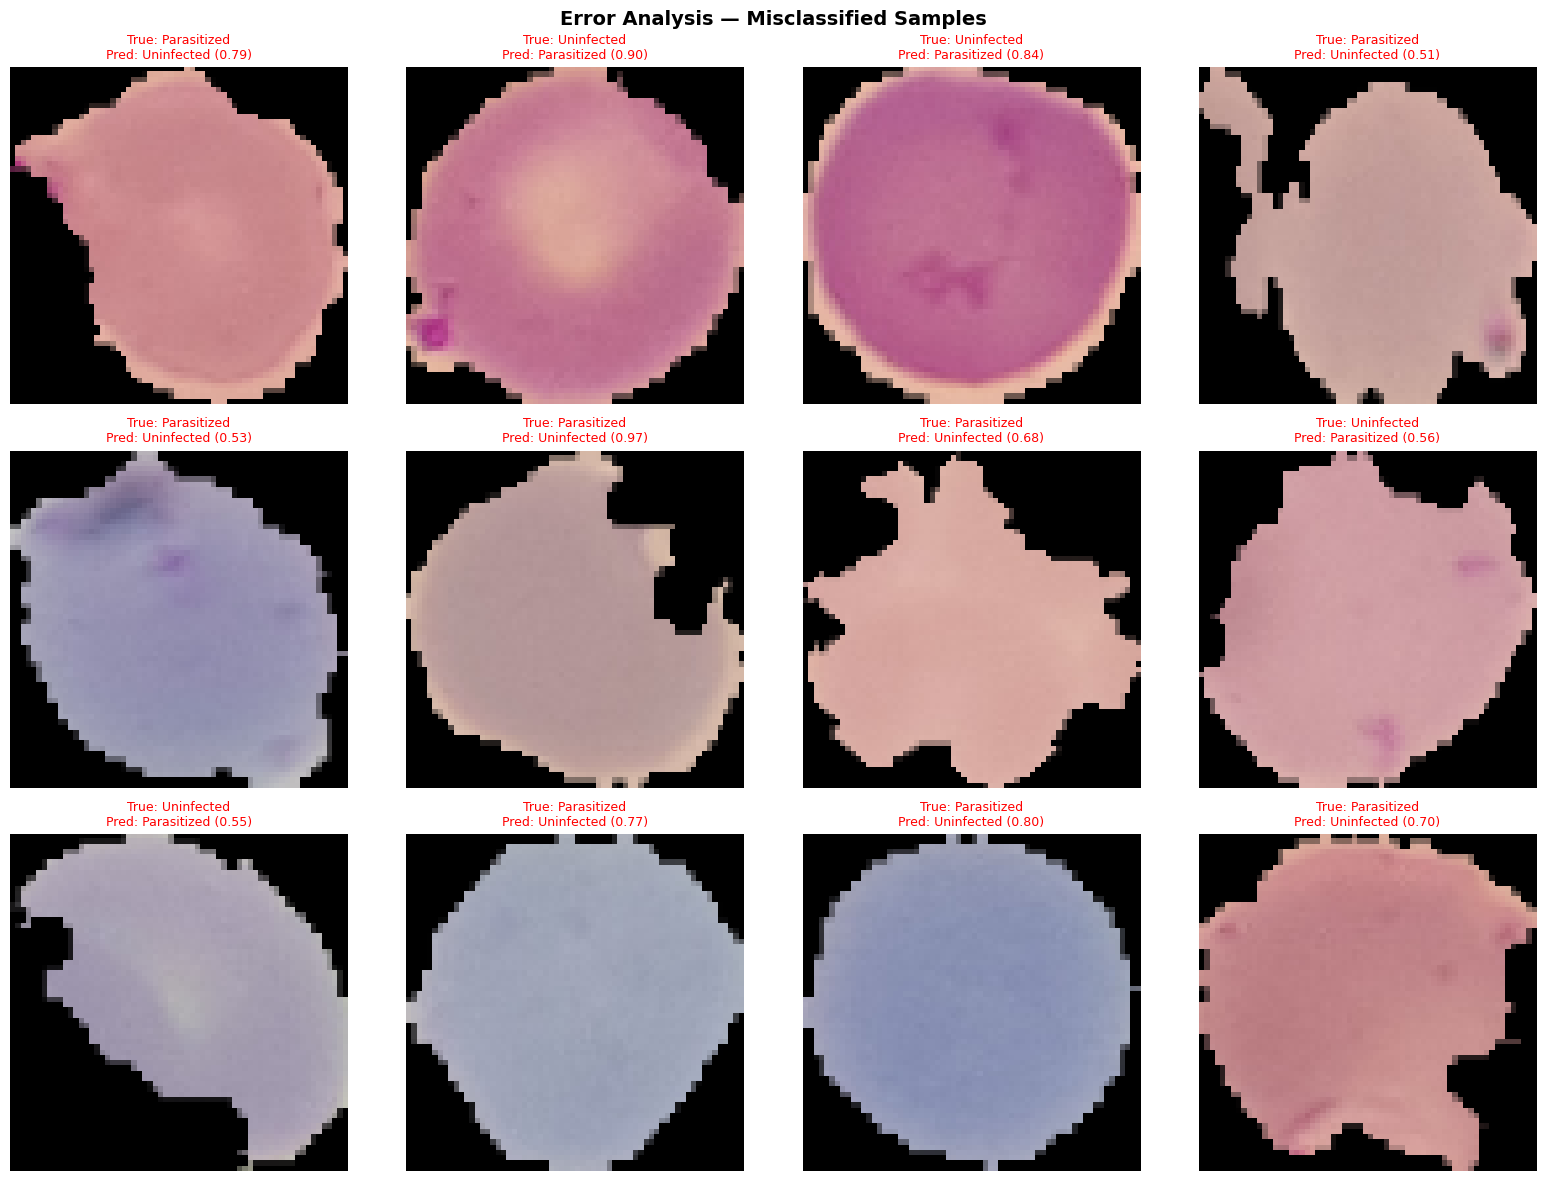

In [21]:
# Use the test_ds that matches the best model's batch size
# (Exp 6 uses test_ds_64; all others use test_ds)
best_test_ds = test_ds_64 if best_exp_num == 6 else test_ds

error_analysis(best_model, best_test_ds, CLASS_NAMES, n_samples=12)

## 9. Model Summary & Report Notes

### Experiment results summary (all 7, Colab T4 GPU run)

| Exp | Description | Accuracy | Precision | Recall | F1 | AUC | Best Epoch |
|-----|-------------|----------|-----------|--------|-----|-----|------------|
| 1 | Baseline LR=1e-3, dropout=0.5 | 0.9576 | 0.9518 | 0.9648 | 0.9582 | 0.9931 | 8 |
| 2 | Lower LR=1e-4 | 0.9572 | 0.9417 | 0.9756 | 0.9583 | 0.9931 | 9 |
| 3 | Higher dropout=0.6 | 0.9587 | 0.9400 | 0.9806 | 0.9599 | 0.9924 | 14 |
| 4 | More filters 64/128/256 | 0.9605 | 0.9451 | 0.9784 | 0.9615 | 0.9916 | 12 |
| **5** | **L2 regularisation λ=1e-4** | **0.9634** | **0.9536** | **0.9748** | **0.9641** | **0.9923** | **13** |
| 6 | Larger batch size=64 | 0.9619 | 0.9497 | 0.9763 | 0.9628 | 0.9933 | 8 |
| 7 | Early stopping patience=5 | 0.9616 | 0.9459 | 0.9799 | 0.9626 | 0.9939 | 10 |

### Best configuration
- **Experiment**: 5 — L2 regularisation (λ=1e-4)
- **Architecture**: 3 Conv blocks (32/64/128 filters), BatchNorm, MaxPooling, Dense(128), Dropout(0.5), L2(1e-4) on all layers
- **Key hyperparameters**: LR=1e-3 (Adam), dropout=0.5, batch_size=32, input=64×64, 20 epochs
- **Test metrics**: Accuracy=0.9634, Precision=0.9536, Recall=0.9748, F1=0.9641, AUC=0.9923

### Clinical relevance
In malaria diagnosis, **Recall (Sensitivity)** is the primary clinical metric. A False Negative represents a parasitised patient classified as uninfected and sent home without treatment — a directly harmful outcome. The best model (Exp 5) achieves Recall=0.9748, meaning 97.48% of infected cells are correctly identified and only 2.52% are missed. While not zero false negatives, this is clinically acceptable for a simple 3-block baseline CNN trained on 64×64 images with no pretrained weights. Precision=0.9536 limits unnecessary follow-up testing for healthy patients.

The highest-Recall model was Exp 3 (dropout=0.6, Recall=0.9806) but its lower Precision (0.9400) and F1 (0.9599) make it less balanced overall. For deployment, Exp 5 offers the best trade-off. The highest AUC was Exp 7 (0.9939), which would be preferred when optimising across all decision thresholds rather than at the 0.5 fixed threshold.

### Observed patterns
- **Most impactful change**: L2 regularisation (Exp 5) produced the largest F1 gain (+0.0059 over baseline)
- **Overfitting**: Present in all experiments; best epoch consistently 8–14, well before the 20-epoch maximum
- **Regularisation effectiveness**: L2 > dropout increase > batch size increase > filter increase > LR reduction
- **AUC vs F1 winner**: Different experiments win depending on metric — Exp 5 for F1/Accuracy, Exp 7 for AUC/Recall balance

### Group model ranking (to be updated after all 5 models complete)
*(Rank this model 1st–5th once all group members have run their experiments and results are compared)*
